# TableTalk — LLM Uncertainty Calibration for Code (Python) & SQL

In our project we explore the difference between the confidence an LLM has in every part of its answer and how often those parts are actually correct by evaluating three black-box uncertainty methods (Verbalized, Tokenized, Consistency) on both our text-to-SQL (BIRD-SQL) datasets and python (HumanEvalPlus and MBPPplus) and one white-box probing method on text-to-SQL (BIRD-SQL).

For each dataset's evaluation, we are only using line-confidences to demonstrate.

Key metrics:

**Brier Skill Score (BSS)**:
    Higher is better, represents whether a certain confidence method performs worse or better than a lazy guess that x% of the time its 1, else 0

**Expected Calibration Error (ECE)**: Lower is better, represents the error between the average confidence in each bucket of confidences, being from 0 - 10%, 11 - 20%, etc., and the average outcome associated with the tokens and lines that are in a bucket respectively (from 0 to 1, closer to 1 means most outcomes in the bucket were in the initially generated solution, closer to 0 means more outcomes in the bucket were removed by a fixer to solve the problem). 

## 1. Install dependencies

In [ ]:
#install dependencies for new environments
!pip install numpy matplotlib -q

## 2. Load Pre-Scored Outputs From Project

First, we are loading in our final HumanEvalPlus, MBPPplus, and BIRD results for both blackbox and whitebox methods from the `final-outputs/` directory.

In [3]:
import json
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

matplotlib.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

OUTPUTS_DIR = Path("final-outputs")

#filenames on disk
FILES = {
    "sql": "sql_bird.jsonl",
    "humaneval": "humaneval.jsonl",
    "mbpp":"mbpp.jsonl",
    "whitebox": "whitebox_sql_bird.json",
}

#load records from a JSON array or JSONL file
def _load_any(path):
    with open(path, encoding="utf-8") as f:
        raw = f.read()
    try:
        data = json.loads(raw)
        if isinstance(data, list): return data
        if isinstance(data, dict):
            for v in data.values():
                if isinstance(v, list): return v
    except json.JSONDecodeError:
        pass
    return [json.loads(line) for line in raw.splitlines() if line.strip()]

#loads the dataset
def load_dataset_records(key):
    path = OUTPUTS_DIR / FILES[key]
    return _load_any(path)

#load our records
sqlRecords = load_dataset_records("sql")
humanevalRecords = load_dataset_records("humaneval")
mbppRecords = load_dataset_records("mbpp")
whiteboxRecords = load_dataset_records("whitebox")

print(f"\nRecords loaded, (len = How many problems) — SQL: {len(sqlRecords)}, HumanEval: {len(humanevalRecords)}, MBPP: {len(mbppRecords)}, Whitebox-SQL: {len(whiteboxRecords)}")


Records loaded, (len = How many problems) — SQL: 1534, HumanEval: 164, MBPP: 378, Whitebox-SQL: 1534


## 3. Dataset Overview
This includes each dataset's size, how many our models passed, how many they failed, and the rate in which they were passed.

The datasets not given an additional modifier, such as **Whitebox**, are using only black-box methods, where as **Whitebox** uses only the white-box approach.

In [4]:
#calculates the pass rate of a given set of dataset results
def pass_rate(results):
    n = len(results)
    passed = sum(1 for r in results if r.get('passed'))
    failed = n - passed
    return {"n": n, "passed": passed, "failed": failed,
            "pass_rate": 100 * passed / n if n else 0}

datasets = {"BIRD-SQL": sqlRecords,
"BIRD-SQL Whitebox": whiteboxRecords,
"HumanEval": humanevalRecords,
"MBPP": mbppRecords}

print(f"{'Dataset':<21}  {'Problems':<5}  {'Passed':>6}  {'Failed':>6}  {'Pass %':>7}")
for name, results in datasets.items():
    s = pass_rate(results)
    print(f"{name:<22}  {s['n']:>6,}  {s['passed']:>6,}  {s['failed']:>6,}  {s['pass_rate']:>6.1f}%")

Dataset                Problems  Passed  Failed   Pass %
BIRD-SQL                 1,534     682     852    44.5%
BIRD-SQL Whitebox        1,534     682     852    44.5%
HumanEval                  164     119      45    72.6%
MBPP                       378     233     145    61.6%


## 4. Calibration metrics — BSS & ECE

We measure uncertainty quality with two metrics:
- **BSS** (Brier Skill Score): $\frac{1 − BS_{model}}{BS_{ref}}$, where $BS_{ref}$ is the lazy model Brier Score and $BS_{model}$ is the Brier Score of the evaluated model itself. Full description described at the beginning. Higher → better.
- **ECE** (Expected Calibration Error): |mean accuracy − mean confidence| per bin. Full description described at the beginning. Lower → better.

Confidence scores come from three line-level sources per record:
`line_array[i] = [line_idx, verbalized_conf, tokenized_conf, consistency_conf, whitebox_conf, passed]`

First, we define the evaluation metric calculation functions:

In [5]:
#brier skill score and expected calibration error calculations
def compute_bss(confs, outcomes):
    if not confs: 
        return float('nan')
    c = np.array(confs, dtype=float)
    o = np.array(outcomes, dtype=float)
    bs = np.mean((c - o) ** 2)
    bs_ref = np.mean((o.mean() - o) ** 2)
    return 1 - bs / bs_ref if bs_ref > 0 else float('nan')

#expected calibration error calculations
def compute_ece(confs, outcomes, n_bins=10):
    if not confs: 
        return float('nan')
    c = np.array(confs, dtype=float)
    o = np.array(outcomes, dtype=float)
    bins = np.linspace(0, 1, n_bins + 1)
    total = len(c)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (c >= lo) & (c < hi)
        if mask.sum() == 0:
            continue
        acc = o[mask].mean()
        conf_m = c[mask].mean()
        ece += mask.sum() / total * abs(acc - conf_m)
    return ece

#extract (conf, outcome) pairs per method from line_array
def collect_line_data(records, conf_indices=(1, 2, 3), methodNames=("Verbalized","Tokenized","Consistency")):
    result = {m: {"confs": [], "outcomes": []} for m in methodNames}
    for rec in records:
        for entry in rec.get('line_array', []):
            if not isinstance(entry, (list, tuple)): 
                continue
            try:
                outcome = float(entry[-1])
                for idx, m in zip(conf_indices, methodNames):
                    if idx < len(entry):
                        result[m]["confs"].append(float(entry[idx]))
                        result[m]["outcomes"].append(outcome)
            except (TypeError, ValueError):
                continue
    return result

Then, we use them to compute BSS and ECE across our datasets for our black-box results:

In [6]:
methodNames = ["Verbalized", "Tokenized", "Consistency"]
dsMap = {"BIRD-SQL": sqlRecords, "HumanEval": humanevalRecords, "MBPP": mbppRecords}

# {dataset: {method: {[token-bss, ece, n], [line-bss, ece, n]}}}
results = {}
for ds_name, recs in dsMap.items():
    ld = collect_line_data(recs)
    results[ds_name] = {}
    for m in methodNames:
        confidences = ld[m]["confs"]; outcomes = ld[m]["outcomes"]
        results[ds_name][m] = {"bss": compute_bss(confidences, outcomes),
                               "ece": compute_ece(confidences, outcomes), 
                               "n": len(confidences)}

print(f"{'Dataset':<14}  {'Method':<14}  {'BSS':>4}  {'ECE':>9}  {'N':>7}")
for dataset in results:
    for method in methodNames:
        result = results[dataset][method]
        print(f"{dataset:<14}  {method:<14}  {result['bss']:>+8.4f}  {result['ece']:>8.4f}  {result['n']:>8,}")

Dataset         Method           BSS        ECE        N
BIRD-SQL        Verbalized       -0.2172    0.2139     6,893
BIRD-SQL        Tokenized        -0.1349    0.1499     6,893
BIRD-SQL        Consistency      -0.2477    0.0939     6,893
HumanEval       Verbalized       -0.0415    0.0321     3,435
HumanEval       Tokenized        -0.3057    0.0627     3,435
HumanEval       Consistency      -0.2444    0.0129     3,435
MBPP            Verbalized       -0.1188    0.1133     6,010
MBPP            Tokenized        -0.1247    0.1251     6,010
MBPP            Consistency      -0.1415    0.0791     6,010


To visualize this better, we graph it below:

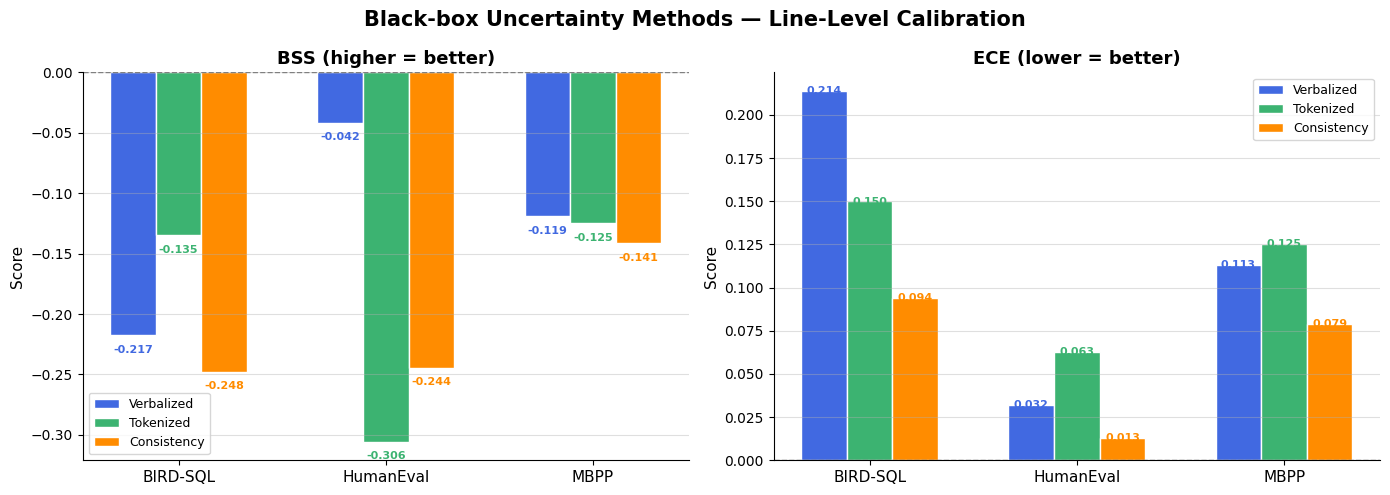

In [7]:
datasetNames = ["BIRD-SQL", "HumanEval", "MBPP"]
colors = {"Verbalized": "royalblue", "Tokenized": "mediumseagreen", "Consistency": "darkorange"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")

metrics = ["bss", "ece"]
titles = ["BSS (higher = better)", "ECE (lower = better)"]

for i in range(2):
    ax = axes[i]
    metric = metrics[i]
    title = titles[i]
    
    x = np.arange(len(datasetNames))
    bw = 0.22
    
    #helper to center grouped bars
    num_methods = len(methodNames)
    start_offset = -(num_methods - 1) * bw / 2
    
    for j in range(num_methods):
        m = methodNames[j]
        offset = start_offset + (j * bw)
        
        #fetch values for the specific metric
        vals = []
        for ds in datasetNames:
            vals.append(results[ds][m][metric])
            
        bars = ax.bar(x + offset, vals, bw, label=m, color=colors[m], edgecolor="white")
        
        for bar in bars:
            h = bar.get_height()
            x_pos = bar.get_x() + (bar.get_width() / 2)
            
            #math for shifting text placement
            if h >= 0:
                y_shift = 0.003 if metric == "bss" else -0.003
                y_pos = h + y_shift
                vert_align = "bottom"
            else:
                y_shift = -0.008 if metric == "bss" else 0.008
                y_pos = h + y_shift
                vert_align = "top"
                
            ax.text(x_pos, y_pos, f"{h:.3f}", ha="center", va=vert_align,
                    fontsize=8, fontweight="bold", color=colors[m])
                    
    ax.axhline(0, color="gray", linewidth=1, linestyle="--")
    ax.set_xticks(x)
    ax.set_xticklabels(datasetNames, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.4)

plt.suptitle("Black-box Uncertainty Methods — Line-Level Calibration", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. White-box Probing Analysis

The white-box method trains a lightweight linear probe, being a Logistic Regression model, on an LLM's middle hidden layer's activations to predict whether each generated token, and subsequently line, will be correct. Unlike the three black-box methods, it has direct access to the model's internal representations.

Data: BIRD-SQL run on the training set — 1,534 SQL queries — `line_array[i][4]`.

In [8]:
#whiteboxRecords already loaded in cell 2 (load_dataset_records("whitebox"))

#extract whitebox confs (index 4) and outcomes (index 5)
wbLineConfs, wbLineOutcomes = [], []

for rec in whiteboxRecords:
    for entry in rec.get('line_array', []):
        if isinstance(entry, (list, tuple)) and len(entry) >= 6 and entry[4] != 0.5:
            wbLineConfs.append(float(entry[4]))
            wbLineOutcomes.append(float(entry[5]))

nPass = sum(1 for r in whiteboxRecords if r.get('passed'))
print(f"Whitebox SQL records : {len(whiteboxRecords):,}  |  Pass rate: {100*nPass/len(whiteboxRecords):.1f}%")
print(f"Whitebox line points : {len(wbLineConfs):,}")
wc = np.array(wbLineConfs)
print(f"Confidence range : {wc.min():.3f} - {wc.max():.3f}  (mean={wc.mean():.3f})")

Whitebox SQL records : 1,534  |  Pass rate: 44.5%
Whitebox line points : 6,296
Confidence range : 0.505 - 0.972  (mean=0.842)


BIRD-SQL — Line-Level Calibration
Method            BSS       ECE       N
Verbalized       -0.2172    0.2139    6,893
Tokenized        -0.1349    0.1499    6,893
Consistency      -0.2477    0.0939    6,893
Whitebox         -0.1375    0.1692    6,296


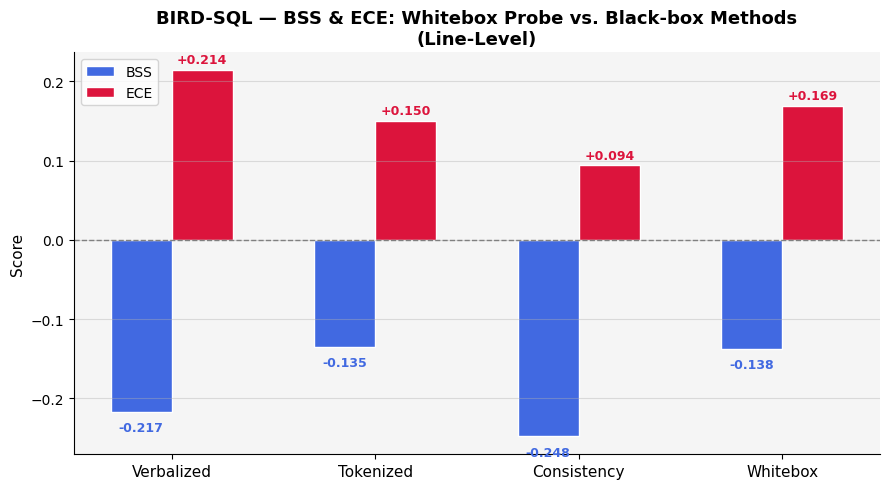

In [9]:
# BSS & ECE: Whitebox vs. Black-box (BIRD-SQL)
sqlLineData = collect_line_data(sqlRecords)

allMethods = ["Verbalized", "Tokenized", "Consistency", "Whitebox"]

allConfs = []
allOutcomes = []

#get data for blackbox methods
for m in methodNames:
    allConfs.append(sqlLineData[m]["confs"])
    allOutcomes.append(sqlLineData[m]["outcomes"])
    
#append whitebox data
allConfs.append(wbLineConfs)
allOutcomes.append(wbLineOutcomes)

wbBssVals = []
wbEceVals = []

#calculate metrics for all 4 methods
for i in range(len(allMethods)):
    conf_arr = allConfs[i]
    out_arr = allOutcomes[i]
    wbBssVals.append(compute_bss(conf_arr, out_arr))
    wbEceVals.append(compute_ece(conf_arr, out_arr))

print("BIRD-SQL — Line-Level Calibration")
print(f"{'Method':<14}  {'BSS':>5}  {'ECE':>8}  {'N':>6}")

for i in range(len(allMethods)):
    m = allMethods[i]
    b = wbBssVals[i]
    e = wbEceVals[i]
    c_len = len(allConfs[i])
    print(f"{m:<14}  {b:>+8.4f}  {e:>8.4f}  {c_len:>7,}")

x = np.arange(len(allMethods))
bw = 0.3

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("whitesmoke")

#plot bars
bars1 = ax.bar(x - bw/2, wbBssVals, bw, label="BSS", color="royalblue", edgecolor="white")
bars2 = ax.bar(x + bw/2, wbEceVals, bw, label="ECE", color="crimson", edgecolor="white")

#addd text labels on top/bottom of each bar
all_bars = list(bars1) + list(bars2)
for bar in all_bars:
    h = bar.get_height()
    x_pos = bar.get_x() + (bar.get_width() / 2)
    
    #adjust alignment based on positive/negative height
    if h >= 0:
        y_pos = h + 0.005
        vert_align = "bottom"
    else:
        y_pos = h - 0.012
        vert_align = "top"
        
    ax.text(x_pos, y_pos, f"{h:+.3f}", ha="center", va=vert_align,
            fontsize=9, fontweight="bold", color=bar.get_facecolor())

#style plot
ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(allMethods, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("BIRD-SQL — BSS & ECE: Whitebox Probe vs. Black-box Methods\n(Line-Level)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.4)

#clean up top/right plot borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()